In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from pathlib import Path
base_path = Path('/content/drive/MyDrive/wakacyjne_wyzwanie_solvro') # change path here!

### Do trenowania modelu użyłem zbioru danych przygotowanego w poprzednim zadaniu



In [3]:
titanic_df = pd.read_csv(base_path/'titanic_preprocessed.csv')
titanic_df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin Letter,Cabin Count,First Cabin Num,Embarked_Q,Embarked_S,Is_Child,Over_three_family_members
0,1,0,3,1,22,1,0,7.2500,0,0,-1,0,1,0,0
1,2,1,1,0,38,1,0,71.2833,3,1,85,0,0,0,0
2,3,1,3,0,26,0,0,7.9250,0,0,-1,0,1,0,0
3,4,1,1,0,35,1,0,53.1000,3,1,123,0,1,0,0
4,5,0,3,1,35,0,0,8.0500,0,0,-1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878,887,0,2,1,27,0,0,13.0000,0,0,-1,0,1,0,0
879,888,1,1,0,19,0,0,30.0000,2,1,42,0,1,0,0
880,889,0,3,0,17,1,2,23.4500,0,0,-1,0,1,1,1
881,890,1,1,1,26,0,0,30.0000,3,1,148,0,0,0,0


### Podział zbioru na treningowy i testowy

In [8]:
X = titanic_df.drop(columns=['PassengerId', 'Survived'])
y = titanic_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67)

### Tworzenie pipelinu dla modeli

In [46]:
models = [
    {
        "model": DummyClassifier(),
        "grid": {
            "strategy": ['most_frequent'],
        }
    },
    {
        "model": KNeighborsClassifier(),
        "grid": {
            "n_neighbors": [3, 5, 7],
            "weights": ['uniform', 'distance'],
        }
    },
    {
        "model": RandomForestClassifier(),
        "grid": {
            "n_estimators": [10, 50, 100],
            "min_samples_split": [2, 5],
        }
    },
    {
        "model": GradientBoostingClassifier(),
        "grid": {
            "learning_rate": [0.1, 0.5, 1, 2],
            "n_estimators": [10, 50, 100],
            "min_samples_split": [2, 5],
        }
    },
    {
        "model": SVC(),
        "grid": {
            "C": [0.1, 1, 10],
            "kernel": ['linear', 'rbf', 'sigmoid'],
        }
    },
]

### Trenowanie modeli

Dla każdego modelu użyłem gridsearcha do znalezienia najlepszych parametrów z walidacją krzyżową ustawioną na 5 próbek.

In [34]:
results = []
hyperparameters_results = []

for entry in models:
    grid_search = GridSearchCV(
        estimator=entry["model"],
        param_grid=entry["grid"],
        cv=5,
        scoring="accuracy",
    )
    grid_search.fit(X_train, y_train)

    results.append({
        "name": entry["model"],
        "best_score": grid_search.best_score_,
        "best_params": grid_search.best_params_,
        "best_estimator": grid_search.best_estimator_,
    })

In [35]:
results

[{'name': DummyClassifier(),
  'best_score': np.float64(0.6163135110503533),
  'best_params': {'strategy': 'most_frequent'},
  'best_estimator': DummyClassifier(strategy='most_frequent')},
 {'name': KNeighborsClassifier(),
  'best_score': np.float64(0.6947710184552289),
  'best_params': {'n_neighbors': 5},
  'best_estimator': KNeighborsClassifier()},
 {'name': RandomForestClassifier(),
  'best_score': np.float64(0.8171679197994989),
  'best_params': {'min_samples_split': 5, 'n_estimators': 100},
  'best_estimator': RandomForestClassifier(min_samples_split=5)},
 {'name': GradientBoostingClassifier(),
  'best_score': np.float64(0.8186716791979951),
  'best_params': {'learning_rate': 0.1,
   'min_samples_split': 5,
   'n_estimators': 50},
  'best_estimator': GradientBoostingClassifier(min_samples_split=5, n_estimators=50)},
 {'name': SVC(),
  'best_score': np.float64(0.7068124857598541),
  'best_params': {'C': 10},
  'best_estimator': SVC(C=10)}]

### Wyniki dla najlepszych modeli

Najważniejszą metryką, którą należy brać pod uwagę jest według mnie recall, ponieważ bardziej zależy nam, aby wszystkie osoby, które potencjalnie mogły przeżyć zostały tak oznaczone (mniej stracimy, gdy kogoś martwego uznamy za potencjalnie żywego i się zawiedziemy, niż gdy uznamy za martwego kogoś, kto w rzeczywistości jest żywy i np. mogliśmy go jeszcze uratować)

- Dummy: biorąc zawsze najliczniejszą klasę (survived=0) otrzymujemy accuracy na poziomie 61%. Jednak precyzja i recall (a co za tym idzie F1 - średnia z tych dwóch metryk) są równe 0 (wartoś TP jest równa 0, bo model wszystko uznał za negative),

- KNN: Accuracy na poziomie 65%, recall tylko 45%. Mało satysfakcjonujący wynik. Widać, że mamy niskie True Positive - uznał mało żywych osób za faktycznie żywe. takie modele są tym gorsze, im większa jest wymiarowość (ilość cech) naszych danych.

- RandomForest: Tutaj bardzo dobry wynik. Wszystkie metryki w miarę wysokie. Cieszy wysoki recall ok 72%. Widać sporo False Negative.

- GradientBoosting: Precyzja lepsza niż w przypadku RandomForest, jednak niższy recalll i podobna ilość False Negative (prawdopodobnie przez podobieństwo modeli)

- Najniższy recall ze wszystkich modeli i większa ilość False Negative niż True Negative. Model nie dopasował się do danych



Model: DummyClassifier()
Accuracy: 0.6153846153846154, Precision: 0.0, Recall: 0.0, F1: 0.0


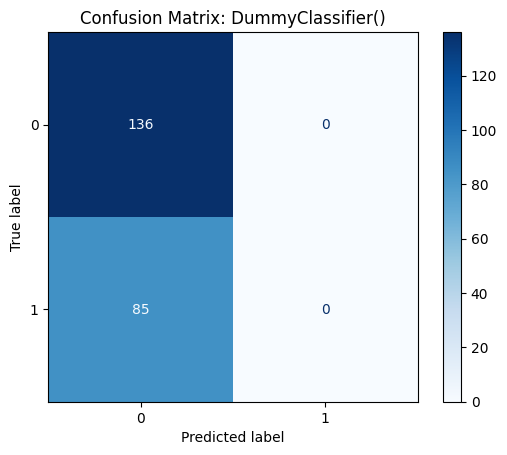



Model: KNeighborsClassifier()
Accuracy: 0.6515837104072398, Precision: 0.5588235294117647, Recall: 0.4470588235294118, F1: 0.49673202614379086


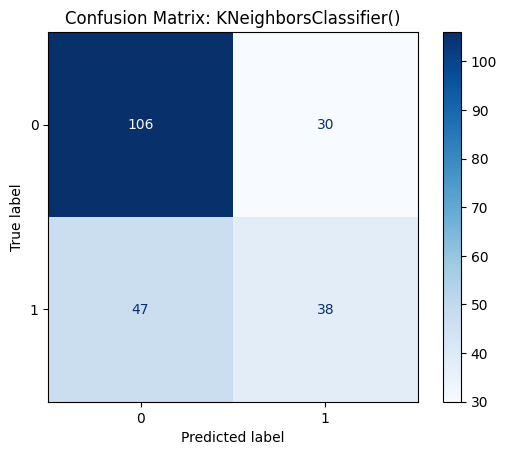



Model: RandomForestClassifier()
Accuracy: 0.832579185520362, Precision: 0.8157894736842105, Recall: 0.7294117647058823, F1: 0.7701863354037267


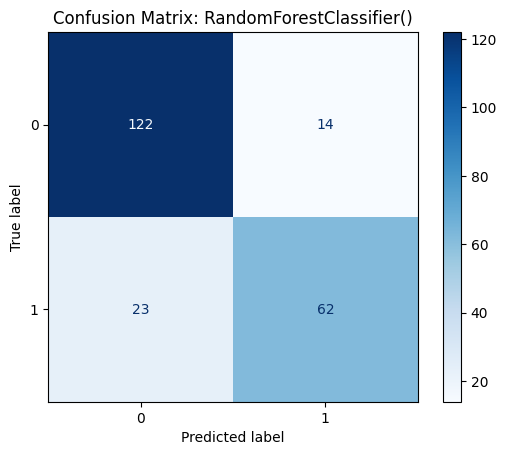



Model: GradientBoostingClassifier()
Accuracy: 0.8190045248868778, Precision: 0.8169014084507042, Recall: 0.6823529411764706, F1: 0.7435897435897436


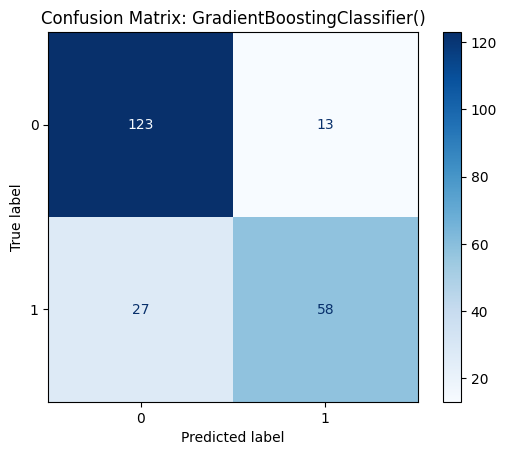



Model: SVC()
Accuracy: 0.6606334841628959, Precision: 0.6190476190476191, Recall: 0.3058823529411765, F1: 0.4094488188976378


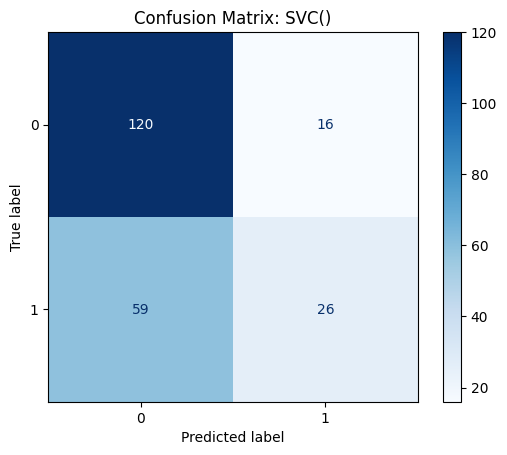

In [45]:
for model in results:
    y_pred = model["best_estimator"].predict(X_test)

    print(f"\n\nModel: {model["name"]}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}, Precision: {precision_score(y_test, y_pred, zero_division=0.0)}, Recall: {recall_score(y_test, y_pred)}, F1: {f1_score(y_test, y_pred)}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix: {model['name']}")
    plt.show()


### Benchmarking hyperparametrów

In [50]:
def test_model(model, results_list):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  results_list.append({
      "accuracy": accuracy_score(y_test, y_pred),
      "precision": precision_score(y_test, y_pred, zero_division=0.0),
      "recall": recall_score(y_test, y_pred),
      "f1": f1_score(y_test, y_pred),
  })

In [55]:
kneighbors_n_neighbors_results = []
kneighbors_n_neighbors = [3, 5, 7, 9, 11]
kneighbors_weights_results = []
kneighbors_weights = ['uniform', 'distance']

randomforest_n_estimators_results = []
randomforest_n_estimators = [10, 20, 50, 100, 200]
randomforest_min_samples_split_results = []
randomforest_min_samples_split = [2, 4, 5, 6, 8]

gradientboosting_learning_rate_results = []
gradientboosting_learning_rate = [0.1, 0.5, 1, 2, 5, 10]
gradientboosting_n_estimators_results = []
gradientboosting_n_estimators = [10, 20, 50, 100, 200]
gradientboosting_min_samples_split_results = []
gradientboosting_min_samples_split = [2, 4, 5, 6, 8]

svc_c_results = []
svc_c = [0.1, 0.5, 1, 2, 5, 10]
svc_kernel_results = []
svc_kernel = ['linear', 'rbf', 'sigmoid']

In [56]:
#KNNClassifier
for n_neighbors in kneighbors_n_neighbors:
  test_model(KNeighborsClassifier(n_neighbors=n_neighbors), kneighbors_n_neighbors_results)

for weights in kneighbors_weights:
  test_model(KNeighborsClassifier(weights=weights), kneighbors_weights_results)

#RandomForestClassifier
for n_estimators in randomforest_n_estimators:
  test_model(RandomForestClassifier(n_estimators=n_estimators), randomforest_n_estimators_results)

for min_samples_split in randomforest_min_samples_split:
  test_model(RandomForestClassifier(min_samples_split=min_samples_split), randomforest_min_samples_split_results)

#GradientBoostingClassifier
for learning_rate in gradientboosting_learning_rate:
  test_model(GradientBoostingClassifier(learning_rate=learning_rate), gradientboosting_learning_rate_results)

for n_estimators in randomforest_n_estimators:
  test_model(GradientBoostingClassifier(n_estimators=n_estimators), gradientboosting_n_estimators_results)

for min_samples_split in randomforest_min_samples_split:
  test_model(GradientBoostingClassifier(min_samples_split=min_samples_split), gradientboosting_min_samples_split_results)

#SVC
for c in svc_c:
  test_model(SVC(C=c), svc_c_results)

for kernel in svc_kernel:
  test_model(SVC(kernel=kernel), svc_kernel_results)



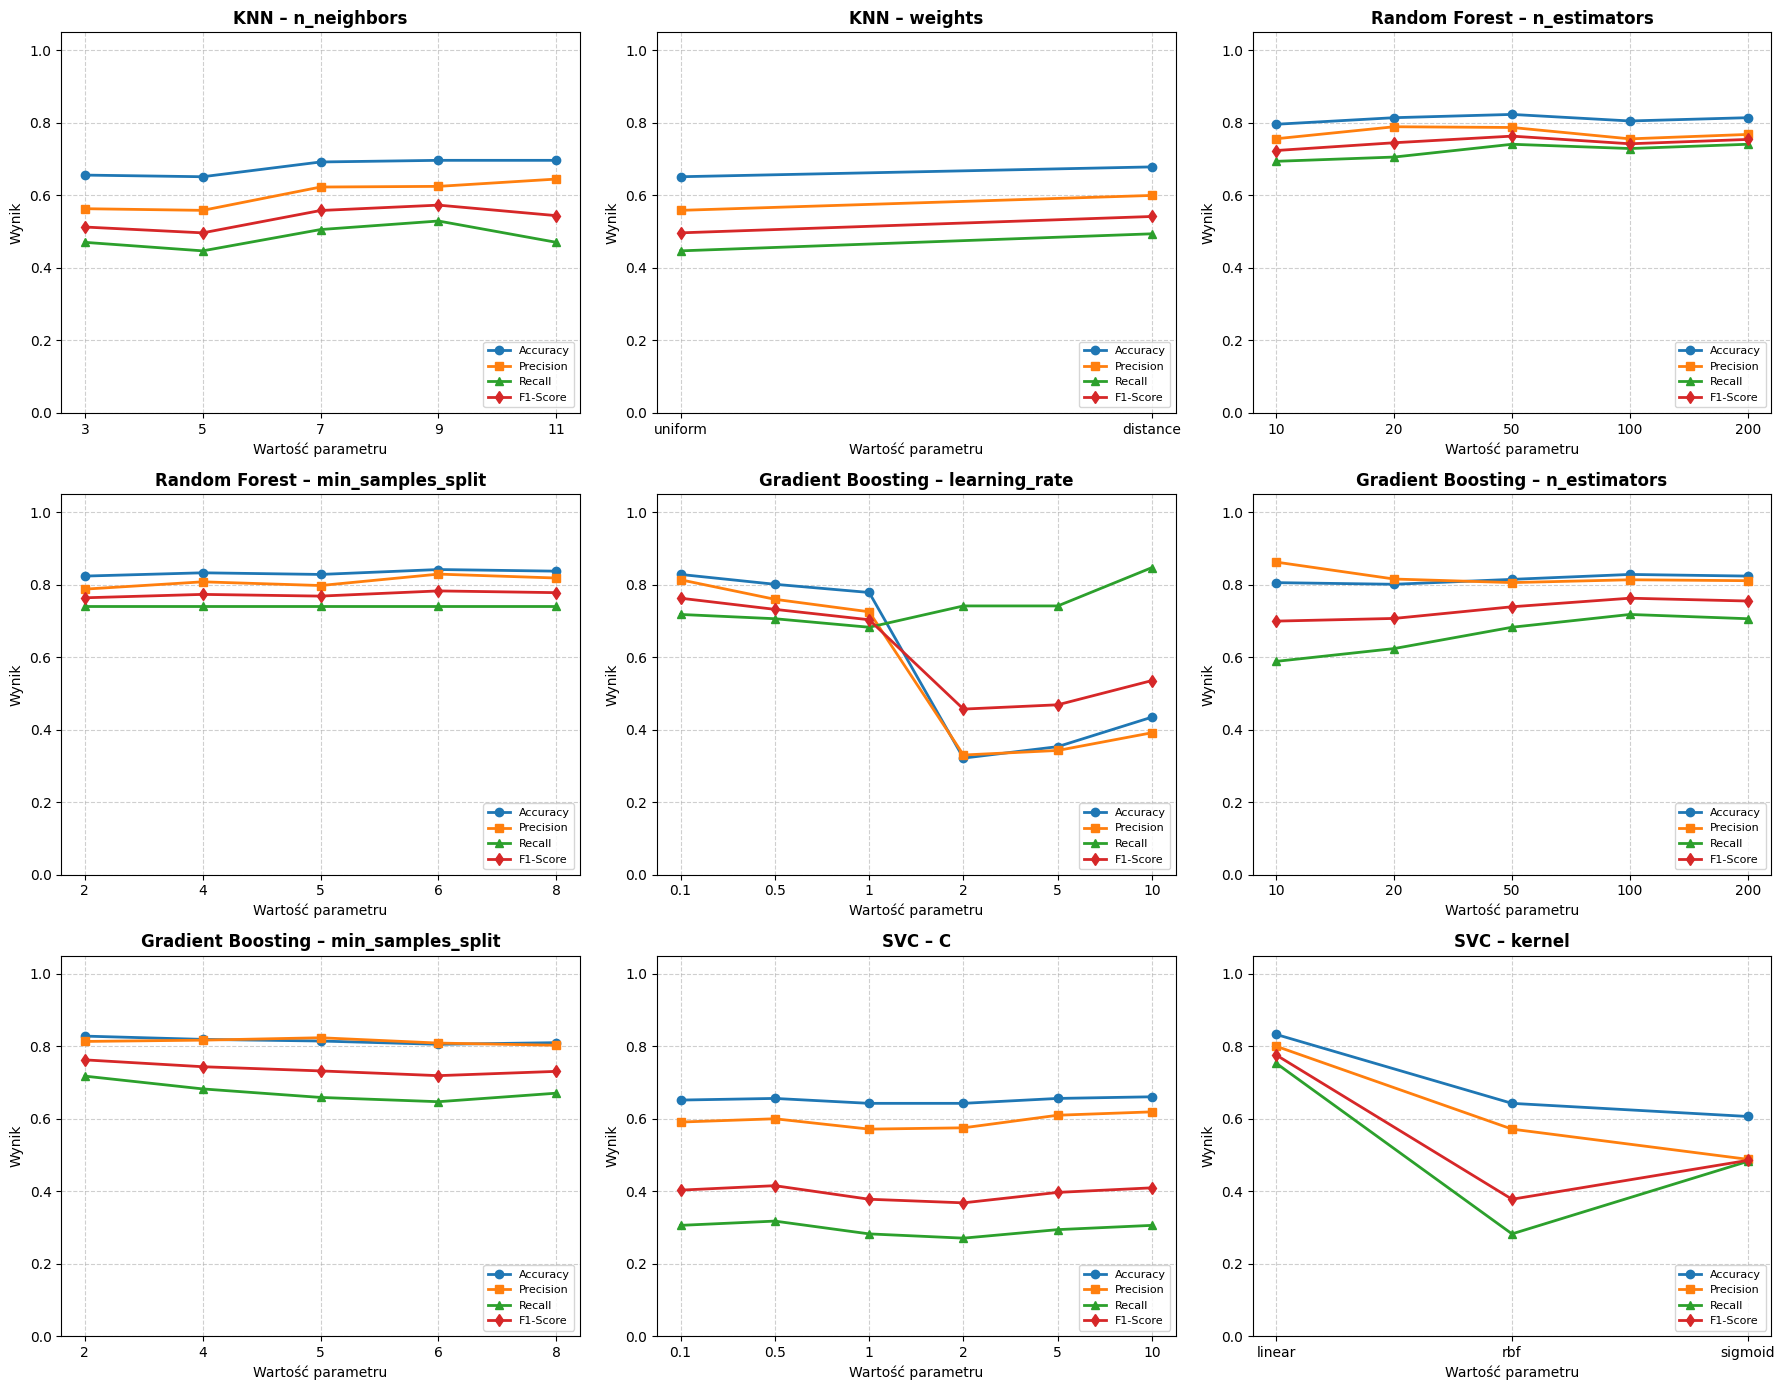

In [57]:
plots_config = [
    ("KNN – n_neighbors", kneighbors_n_neighbors, kneighbors_n_neighbors_results),
    ("KNN – weights", kneighbors_weights, kneighbors_weights_results),
    (
        "Random Forest – n_estimators",
        randomforest_n_estimators,
        randomforest_n_estimators_results,
    ),
    (
        "Random Forest – min_samples_split",
        randomforest_min_samples_split,
        randomforest_min_samples_split_results,
    ),
    (
        "Gradient Boosting – learning_rate",
        gradientboosting_learning_rate,
        gradientboosting_learning_rate_results,
    ),
    (
        "Gradient Boosting – n_estimators",
        gradientboosting_n_estimators,
        gradientboosting_n_estimators_results,
    ),
    (
        "Gradient Boosting – min_samples_split",
        gradientboosting_min_samples_split,
        gradientboosting_min_samples_split_results,
    ),
    ("SVC – C", svc_c, svc_c_results),
    ("SVC – kernel", svc_kernel, svc_kernel_results),
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

metrics = ["accuracy", "precision", "recall", "f1"]
styles = {
    "accuracy": {"color": "#1f77b4", "marker": "o", "label": "Accuracy"},
    "precision": {"color": "#ff7f0e", "marker": "s", "label": "Precision"},
    "recall": {"color": "#2ca02c", "marker": "^", "label": "Recall"},
    "f1": {"color": "#d62728", "marker": "d", "label": "F1-Score"},
}

for ax, (title, x_vals, results) in zip(axes, plots_config):
    df_results = pd.DataFrame(results)

    for metric in metrics:
        ax.plot(
            [str(v) for v in x_vals],
            df_results[metric],
            label=styles[metric]["label"],
            color=styles[metric]["color"],
            marker=styles[metric]["marker"],
            linewidth=2,
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Wartość parametru", fontsize=10)
    ax.set_ylabel("Wynik", fontsize=10)
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

### Wnioski
Widać, że największy wpływ na jakość modelu miały:

- ilość sąsiadów dla KNN (to jest często game changer, może znacząco zmienić zachowanie modelu),

- n_estimators dla RandomForest (im więcej estymatorów tym mniejsza wariancja - takie jest clue RandomForest),

- learning rate dla Gradient Boostingu (recall jako jedyny jest wyższy, ale uważam, że to dobrze bo to najważniejsza matryka - zwiększanie learning rate'a zmniejsza szansę na trafienie w dobre minimum dla gradientu),

- n_estimators dla Gradient Boostingu (analogicznie jak w RandomForest),

- kernel dla SVC (najlepszy okazał się linear, więc dane muszą układać się liniowo)